# Initial Validation Experiments

This section establishes a set of controlled experiments using manually constructed relationships between variables. The purpose is to verify whether PCA and information-theoretic measures, particularly mutual information (MI) and conditional mutual information (CMI), can correctly identify known dependencies between parameters, before these methods are appplied to real data.

Starting from simple linear combinations provides a baseline where the underlying relationships are explicitly known. The experiments are then extended to nonlinear combinations and other controlled settings, allowing the behaviour and limitations of the different methods to be examined under increasingly complex relationships.

These experiments serve as an initial validation of the analysis pipeline. In particular, they provide a reference for interpreting the results obtained later, where the underlying relationships between parameters are no longer known in advance.

## Imports


#### Dependencies

Run this first vvv

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from npeet import entropy_estimators as ee
from sklearn.decomposition import PCA
from scipy.optimize import minimize
from fractions import Fraction

pca = PCA()

### Background Notes

#### PCA: Principle Component Analysis

Analysis tool used to determine principle component, in other words identify the directions along which the data varies the most.

PC1 is defined as the direction of max variance which contains most information. PC2 is orthogonal to PC1, capturing remaining variance.

##### Theoretical

Given a centered data matrix

$$
X \in \mathbb{R}^{n \times p}
$$

the covariance matrix is

$$
C = \frac{1}{n-1}X^TX
$$

PCA computes the eigenvalue decomposition (very similar to SVD)

$$
C = V\Lambda V^T
$$

where:

- $V$: eigenvectors (principal directions)
- $\Lambda$: eigenvalues (variance explained by each direction)

The principal components are ordered according to decreasing eigenvalues.

##### Application Use

*For use, refer to https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html for more details*


#### EE: Entropy Estimator

##### Theoretical

###### MI

Given two random variables \(X\) and \(Y\), with joint distribution

$$
p(x,y)
$$

and marginal distributions

$$
p(x), \quad p(y),
$$

the mutual information is defined as

$$
I(X;Y)
=
\int\int
p(x,y)
\log
\frac{p(x,y)}
     {p(x)p(y)}
\,dx\,dy
$$

Equivalent entropy-based formulations are

$$
I(X;Y)
=
H(X)-H(X|Y)
$$

$$
I(X;Y)
=
H(Y)-H(Y|X)
$$

$$
I(X;Y)
=
H(X)+H(Y)-H(X,Y)
$$

where:

- \(H(X)\): entropy of \(X\)
- \(H(Y)\): entropy of \(Y\)
- \(H(X,Y)\): joint entropy
- \(H(X|Y)\): conditional entropy

Interpretation:

- \(I(X;Y)=0\): \(X\) and \(Y\) are independent
- Larger \(I(X;Y)\): stronger dependence
- Captures both linear and nonlinear relationships

###### CMI

Given three random variables \(X\), \(Y\), and \(Z\), the conditional mutual information is defined as

$$
I(X;Y|Z)
=
\iiint
p(x,y,z)
\log
\frac{p(x,y|z)}
     {p(x|z)p(y|z)}
\,dx\,dy\,dz
$$

Equivalent entropy formulation:

$$
I(X;Y|Z)
=
H(X|Z)-H(X|Y,Z)
$$

or

$$
I(X;Y|Z)
=
H(X,Z)+H(Y,Z)-H(Z)-H(X,Y,Z)
$$

where:

- \(H(X|Z)\): conditional entropy of \(X\) given \(Z\)
- \(H(X|Y,Z)\): remaining uncertainty in \(X\) after observing \(Y\) and \(Z\)

Interpretation:

- \(I(X;Y|Z)=0\): \(X\) and \(Y\) are conditionally independent given \(Z\)
- Large values indicate dependence remains even after conditioning on \(Z\)


##### Application Use

*The NPEET library uses a KNN algorithm for calculation, so the result might be < 0*

*For use, refer to https://github.com/gregversteeg/NPEET for more details*

## Linear Combination (without noise)

In this section, some linear combinations of parameters will be tested through both entropy test and PCA, and comparing their results. 

It is suggested to check with manually constructed relationships first. Some helper functions are defined as below:

In [3]:
#helper functions
def show_2d(x,y): #visualisation
    plt.figure(figsize=(3, 3))
    plt.scatter(x, y)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis('equal') 
    plt.show()
    
def show_3d(a,b,y): #visualisation
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(a, b, y, s=5)
    ax.set_xlabel('a')
    ax.set_ylabel('b')
    ax.set_zlabel('y')
    ax.view_init(elev=30, azim=45)

    plt.show()
    
def pca_2d(a,b,y): #data
    print("PCA:")
    pca.fit(np.column_stack([y, a]))
    print(pca.components_)
    print("Variance ratio (y,a): " + str(pca.explained_variance_ratio_))
    pca.fit(np.column_stack([y, b]))
    print(pca.components_)
    print("Variance ratio (y,b): " + str(pca.explained_variance_ratio_))
    pca.fit(np.column_stack([a, b, y]))
    print(pca.components_)
    print("Variance ratio (a,b,y): " + str(pca.explained_variance_ratio_))
    print("--------------------------")
    
def ee_2d(a,b,y): #data
    print("EE:")
    print("I(y;a): " + str(ee.mi(y,a)))
    print("I(y;b): " + str(ee.mi(y,b)))
    print("I(a;y|b): " + str(ee.cmi(a,y,b)))
    print("I(b;y|a): " + str(ee.cmi(b,y,a)))
    print("--------------------------")
    

In [4]:
#run this first and get randomly generated a & b
a = np.random.randn(1000)
b = np.random.randn(1000)

In [42]:
#define your y here
y = 2*a + 0.5*b

EE:
I(y;a): 2.132189640565435
I(y;b): -0.01916522087867777
I(a;y|b): 3.7242823592038987
I(b;y|a): 1.5079086568639561
--------------------------
PCA:
[[ 0.90164625  0.43247432]
 [-0.43247432  0.90164625]]
Variance ratio (y,a): [0.99162137 0.00837863]
[[ 0.99205466  0.12580761]
 [-0.12580761  0.99205466]]
Variance ratio (y,b): [0.83429114 0.16570886]
[[ 0.42778987  0.08800754  0.89958351]
 [-0.23471485  0.97192367  0.01653213]
 [ 0.87287156  0.21821789 -0.43643578]]
Variance ratio (a,b,y): [8.50948736e-01 1.49051264e-01 3.84811578e-18]
--------------------------


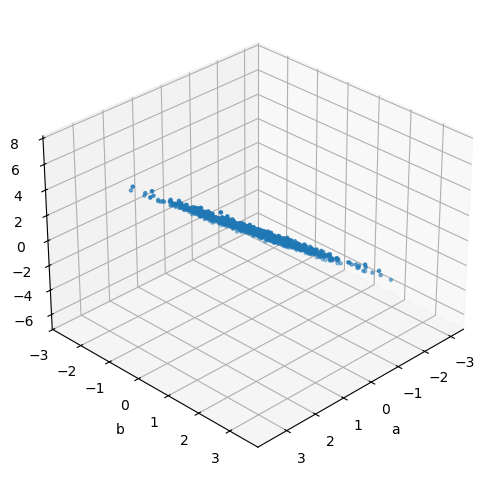

In [43]:
#results
ee_2d(a,b,y)
pca_2d(a,b,y)
show_3d(a,b,y)

#### Interpretation

PCA extracts orthogonal directions that explain the variance structure of the data. The first term in pca_components is the direction that maximises the variance (change). If the associated variance is close to zero, it may indicate an approximate linear constraint among the variables.

The interpretation approach is to check the explained variance ratio of the last principal component. When the value is negligible (the threshold is set to be 1e-8), it suggests that the corresponding eigenvector may represent an approximate linear relationship among the variables.. Fraction module is used to approximate the ratio. Note that although the interpreter works well on manually constructed relationships, it is not tested against actual experiment data.

The interpreter function below takes 3 parameters, pca_components, pca_ratio and param_names. The last argument is optional.

The exact format of the restored relationship (which term sits on LHS) depends on the argument order passed to pca calculation function.

In [10]:
def pca_interpretation(components, ratio, param_names=None):
    print("=====PCA=====")
    if len(ratio) != len(components):
        print("Invalid inputs")
        return
    if ratio[-1] >= 1e-6: #when the last component ratio is negletable, it means this direction fits orginal correlation well
        print("No significant linear relationship is found in this PCA analysis.")
        return
    v = np.array(components[-1])
    v = v / np.min(np.abs(v[np.abs(v) > 1e-8])) #threshold
    coeffs = [Fraction(x).limit_denominator(10) for x in v]
    
    print("Detected ratio:")
    print(coeffs)
    
    if param_names is None:
        param_names = [chr(ord('a') + i) for i in range(len(coeffs))] #ascii
        
    lhs_coeff = -coeffs[-1]
    lhs_var = param_names[-1]

    rhs_terms = []

    for c, name in zip(coeffs[:-1], param_names[:-1]):

        if c == 0:
            continue

        sign = "+" if c > 0 else "-"

        rhs_terms.append(
            (sign, abs(c), name)
        )

    equation = f"{lhs_coeff}{lhs_var} = "

    first = True

    for sign, c, name in rhs_terms:

        if first:
            if sign == "-":
                equation += "-"
            equation += f"{c}{name}"
            first = False
        else:
            equation += f" {sign} {c}{name}"

    print("\nApproximate relation:")
    print(equation)

EE result interpretation:

Optimisation is used here for searching over fitting coefficients. Scipy.optimize library is used, refer to: https://docs.scipy.org/doc/scipy/tutorial/optimize.html for more details.

Note that ee result interpretation only reveals a correlation in coefficients, instead of a real "y = ..." relationship.

It does not work well when parameters' coefficient magnitude differs by too much.

In [40]:
def ee_objective(coeffs, X, y):
    coeffs = np.asarray(coeffs, dtype=float)
    coeffs /= np.linalg.norm(coeffs)
    u = X @ coeffs
    return ee.mi(y, u)

def scipy_objective(coeffs, X, y):
    return -ee_objective(coeffs, X, y)
    
def ee_interpretation_scipy(X,y,param_names=None,method="Powell"):
    print("=====EE (SciPy)=====")
    
    X = np.asarray(X)
    n = X.shape[1]
    initial_guess=np.ones(X.shape[1])
    
    if param_names is None:
        if n <= 26:
            param_names = [chr(ord('a') + i) for i in range(n)]
        else:
            param_names = [f"x{i}" for i in range(n)]

    if initial_guess is None:
        initial_guess = np.ones(n)

    result = minimize(scipy_objective, x0=np.asarray(initial_guess, dtype=float), args=(X, y), method=method)

    #result display
    coeff = result.x.astype(float)
    coeff /= np.linalg.norm(coeff)
    
    z = X @ coeff
    gamma = np.cov(z, y, bias=True)[0,1] / np.var(z)
    coeff = gamma * coeff
    
    idx = np.argmax(np.abs(coeff))
    if coeff[idx] < 0:
        coeff *= -1

    print(f"Success : {result.success}")
    print(f"Iterations : {result.nit}")
    print(f"Function evaluations : {result.nfev}")
    print(f"Maximum MI : {-result.fun:.6f}")

    print("\nRecovered direction:")
    terms = []
    for c, name in zip(coeff, param_names):
        terms.append(f"{c:.6f}{name}")

    print(" + ".join(terms))

    coeff2 = coeff.copy()

    coeff2[np.abs(coeff2) < 1e-6] = 0

    ratios = [
        Fraction(x).limit_denominator(20)
        for x in coeff2
    ]

    print("\nApproximate coefficients:")
    print(ratios)

    relation = " + ".join(
        f"{r}{name}"
        for r, name in zip(ratios, param_names)
    )

    print("\nApproximate relationship:")
    print(f"y ∝ {relation}")

In [44]:
#example use
pca_interpretation(pca.components_, pca.explained_variance_ratio_)
ee_interpretation_scipy(np.column_stack((a, b)),y)

=====PCA=====
Detected ratio:
[Fraction(4, 1), Fraction(1, 1), Fraction(-2, 1)]

Approximate relation:
2c = 4a + 1b
=====EE (SciPy)=====
Success : True
Iterations : 2
Function evaluations : 113
Maximum MI : 7.320126

Recovered direction:
1.999998a + 0.500011b

Approximate coefficients:
[Fraction(2, 1), Fraction(1, 2)]

Approximate relationship:
y ∝ 2a + 1/2b


### 3D & Higher Dimensions

Here, a generator is provided for random coefficients.

In [17]:
def generate_linear_problem(
        n,
        sample_size=1000,
        coeff_range=(-20,20),
        seed=None):
    if seed is not None:
        np.random.seed(seed)

    X = np.random.randn(sample_size, n)
    coeffs = np.random.randint(
        coeff_range[0],
        coeff_range[1] + 1,
        size=n
    )
    while np.all(coeffs == 0):
        coeffs = np.random.randint(
            coeff_range[0],
            coeff_range[1] + 1,
            size=n
        )
    y = X @ coeffs
    return X, y, coeffs

def pca_nd(X, y):
    data = np.column_stack([X, y])
    pca.fit(data)
    print("PCA:")
    print(pca.components_)
    print("Variance ratio:")
    print(pca.explained_variance_ratio_)

def ee_nd(X, y):
    n = X.shape[1]
    print("EE:")

    for i in range(n):
        print(
            f"I(y;x{i+1}): "
            + str(ee.mi(y, X[:, i]))
        )

    for target in range(n):

        others = [j for j in range(n) if j != target]

        for cond in others:

            print(
                f"I(x{target+1};y|x{cond+1}): "
                + str(
                    ee.cmi(
                        X[:, target],
                        y,
                        X[:, cond]
                    )
                )
            )
    print("--------------------------")

In [19]:
#helper functions
def ee_3d(a,b,c,y):
    print("EE:")
    print("I(y;a): " + str(ee.mi(y,a)))
    print("I(y;b): " + str(ee.mi(y,b)))
    print("I(y;c): " + str(ee.mi(y,b)))
    print("I(a;y|b): " + str(ee.cmi(a,y,b)))
    print("I(b;y|a): " + str(ee.cmi(b,y,a)))
    print("I(c;y|b): " + str(ee.cmi(c,y,b)))
    print("I(c;y|a): " + str(ee.cmi(c,y,a)))
    print("I(a;y|c): " + str(ee.cmi(a,y,c)))
    print("I(b;y|c): " + str(ee.cmi(b,y,c)))
    print("--------------------------")
    
def pca_3d(a,b,c,y): #pca result becomes hard to interpret so normalisation is used here
    print("PCA:")
    pca.fit(np.column_stack([a, b, c, y]))
    print(pca.components_)
    print("Variance ratio: " + str(pca.explained_variance_ratio_))
    print("--------------------------")

In [36]:
X,y,c = generate_linear_problem(5) #an example randomly-generated linear combination
print(c) #coefficients
pca_nd(X,y)
ee_nd(X,y)

[  3  -9 -12  16  13]
PCA:
[[ 3.65781800e-03 -1.38612861e-02 -1.80262933e-02  2.40701153e-02
   2.01599379e-02  9.99241585e-01]
 [ 5.45071785e-01 -2.30140308e-01  5.20561593e-01 -2.84693110e-01
   5.45800005e-01  4.93210860e-05]
 [ 6.60689745e-01 -1.80763468e-01 -5.32864581e-01 -3.09079508e-01
  -3.89022180e-01  7.54944739e-04]
 [-2.87896312e-02  6.50554481e-01 -4.21713778e-01 -3.63809255e-01
   5.15509774e-01 -1.14908718e-04]
 [ 5.01903600e-01  6.06810899e-01  2.20729905e-01  5.50094863e-01
  -1.68957810e-01  7.20127797e-04]
 [ 1.16774842e-01 -3.50324525e-01 -4.67099366e-01  6.22799155e-01
   5.06024314e-01 -3.89249472e-02]]
Variance ratio:
[0.99418905 0.00156184 0.0015037  0.00142109 0.00132432 0.        ]
EE:
I(y;x1): 0.03788256968457365
I(y;x2): 0.0932601413246795
I(y;x3): 0.12942829977780768
I(y;x4): 0.3347276371913033
I(y;x5): 0.1973782290668824
I(x1;y|x2): 0.01467657360027376
I(x1;y|x3): -0.0247834079504144
I(x1;y|x4): 0.017571378515005766
I(x1;y|x5): -0.01558529337009776
I(x2;y

In [37]:
pca_interpretation(pca.components_, pca.explained_variance_ratio_)
ee_interpretation_scipy(X,y)

=====PCA=====
Detected ratio:
[Fraction(3, 1), Fraction(-9, 1), Fraction(-12, 1), Fraction(16, 1), Fraction(13, 1), Fraction(-1, 1)]

Approximate relation:
1f = 3a - 9b - 12c + 16d + 13e
=====EE (SciPy)=====
Success : True
Iterations : 5
Function evaluations : 431
Maximum MI : 3.829495

Recovered direction:
3.062563a + -8.991100b + -11.936094c + 16.017506d + 13.030318e

Approximate coefficients:
[Fraction(49, 16), Fraction(-9, 1), Fraction(-191, 16), Fraction(16, 1), Fraction(261, 20)]

Approximate relationship:
y ∝ 49/16a + -9b + -191/16c + 16d + 261/20e


EE gives an approximate measure of the coefficients.

Up to now, PCA and EE are both verified to work well on linear problems (and with no noise).

## Non-Linear Combination (Manually generated)

Some non-linear combinations will be tested.

In [22]:
#define your y here
y = a**2

EE:
I(y;a): 6.295229687220413
I(y;b): 0.056499082051508276
I(a;y|b): 2.5981782953910173
I(b;y|a): -0.0666113085651853
--------------------------
PCA:
[[ 0.99326625 -0.11585404]
 [ 0.11585404  0.99326625]]
Variance ratio (y,a): [0.68585639 0.31414361]
[[ 0.9997931   0.02034083]
 [-0.02034083  0.9997931 ]]
Variance ratio (y,b): [0.70369961 0.29630039]
[[-0.11598983  0.02106167  0.99302707]
 [ 0.98770644 -0.10303927  0.11755377]
 [ 0.10479667  0.99445428 -0.00885124]]
Variance ratio (a,b,y): [0.53308237 0.2443364  0.22258123]
--------------------------


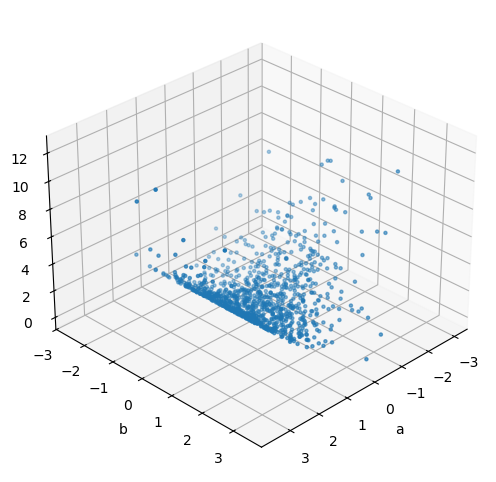

In [23]:
#results
ee_2d(a,b,y)
pca_2d(a,b,y)
show_3d(a,b,y)

In [24]:
pca_interpretation(pca.components_, pca.explained_variance_ratio_)


=====PCA=====
No significant linear relationship is found in this PCA analysis.


PCA fails to work for nonlinear problems, while ee is still giving information of "a" highly related to y. (the interpretor doesn't give meaningful output for nonlinear combinations now)

## Linear Combination (with noise)

As shown above, pure linear combinations can be easily recognised by PCA method, with a very high accuracy.

In this section some noise will be introduced to data and see the comparison between two methods.

Noise_level is defined in the cell below, and modifications could be made to change the noise level. Note that noise level here is __not percentage__.

In [45]:
#noise set-up
noise_level = [0, 0.002, 0.05, 0.1, 0.2, 0.5, 1] #values

def add_noise(y):
    ys = []

    for sigma in noise_level:
        noise = np.random.normal(
            0,
            sigma,
            len(y)
        )
        ys.append(y + noise)

    return ys

In [46]:
y = 7*a + 3*b

In [49]:
#results
ys = add_noise(y)

for sigma, y_noisy in zip(noise_level, ys):
    print(f"Noise level = {sigma}")
    ee_2d(a, b, y_noisy)
    pca_2d(a, b, y_noisy)
    pca_interpretation(pca.components_, pca.explained_variance_ratio_)
    ee_interpretation_scipy(np.column_stack((a, b)),y_noisy)
    print("===========================")

Noise level = 0
EE:
I(y;a): 1.390431333622159
I(y;b): 0.0842959947673125
I(a;y|b): 2.86326642539951
I(b;y|a): 1.430994500049742
--------------------------
PCA:
[[ 0.99247539  0.12244425]
 [-0.12244425  0.99247539]]
Variance ratio (y,a): [0.99755455 0.00244545]
[[ 0.9989056   0.04677183]
 [-0.04677183  0.9989056 ]]
Variance ratio (y,b): [0.98648922 0.01351078]
[[ 0.12205422  0.04569712  0.9914709 ]
 [-0.39318481  0.91943972  0.00602551]
 [ 0.91132238  0.39056673 -0.13018891]]
Variance ratio (a,b,y): [9.84247665e-01 1.57523348e-02 1.00319006e-16]
--------------------------
=====PCA=====
Detected ratio:
[Fraction(7, 1), Fraction(3, 1), Fraction(-1, 1)]

Approximate relation:
1c = 7a + 3b
=====EE (SciPy)=====
Success : True
Iterations : 2
Function evaluations : 92
Maximum MI : 5.552617

Recovered direction:
7.005110a + 2.986307b

Approximate coefficients:
[Fraction(7, 1), Fraction(3, 1)]

Approximate relationship:
y ∝ 7a + 3b
Noise level = 0.002
EE:
I(y;a): 1.3902220703941945
I(y;b): 0.084

As noise level increases, PCA's ability to recognise linear combinations decreases very fast. It could barely handle data with noises.

In contrast, entropy estimator still recognises coefficients even with a strong noise. Note that with the introduction of noise, sometimes a relationship like "y = 2a" will get very weird results in ee_interpretation.

Exponential relationships can also be tested via taking logs of a and b (as shown below).


In [53]:
a = np.random.uniform(1, 10, 1000)
b = np.random.uniform(1, 10, 1000)
y = 5*a*b**0.5

In [54]:
log_a = np.log(a)
log_b = np.log(b)
log_y = np.log(y)
X = np.column_stack([log_a, log_b])
ee_interpretation_scipy(X,log_y)

=====EE (SciPy)=====
Success : True
Iterations : 2
Function evaluations : 117
Maximum MI : 8.040891

Recovered direction:
0.999985a + 0.500034b

Approximate coefficients:
[Fraction(1, 1), Fraction(1, 2)]

Approximate relationship:
y ∝ 1a + 1/2b


## Conclusion

Based on the experimental results above, we can conclude that, when searching for relationships between parameters and (y), PCA is only suitable for identifying relationships under relatively low noise and linear assumptions. In real-world data, however, noise is inevitable, and it is also unlikely that parameter relationships can be adequately described by simple linear relationships.

The EE approach, on the other hand, can still provide useful results in the presence of nonlinear relationships and even relatively high levels of noise. This suggests that information-theoretic methods may provide a promising direction for discovering parameter correlations.

In the current version of this notebook, the ee_interpretation function can only fit linear relationships. This limitation will be addressed in future work by introducing other methods.